# Tutorial: Integrate an iterative solver into a PorePy model.

Let's start with setting up an example model. 

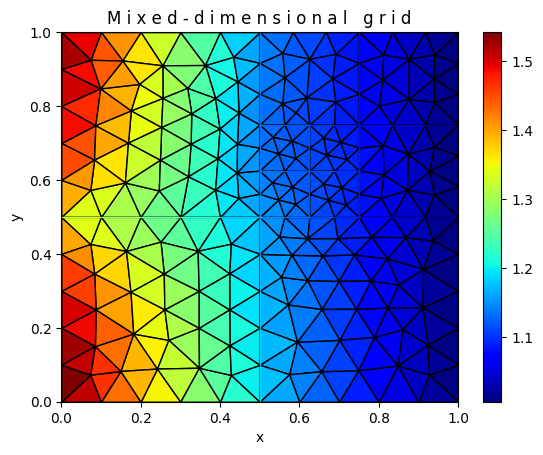

EquationSystem for mixed-dimensional grid with 16 subdomains and 24 interfaces.
There are in total 2 variables, distributed as follows:
	interface_darcy_flux is present on interfaces with id: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23	pressure is present on subdomains with id: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15
In total 3 equations, with names: 
	mass_balance_equation
	interface_darcy_flux_equation
	well_flux_equation



In [1]:
import porepy as pp
from porepy.examples.flow_benchmark_2d_case_1 import (
    FlowBenchmark2dCase1Model,
    solid_constants_conductive_fractures,
)

model_params = {
    "material_constants": {"solid": solid_constants_conductive_fractures},
    "grid_type": "simplex",
    "meshing_arguments": {"cell_size": 0.1},
}
model = FlowBenchmark2dCase1Model(model_params)
pp.run_time_dependent_model(model)
pp.plot_grid(model.mdg, cell_value='pressure', plot_2d=True)

print(model.equation_system)

The iterative solver can be plugged into the model using the `IterativeLinearSolver` mixin class:

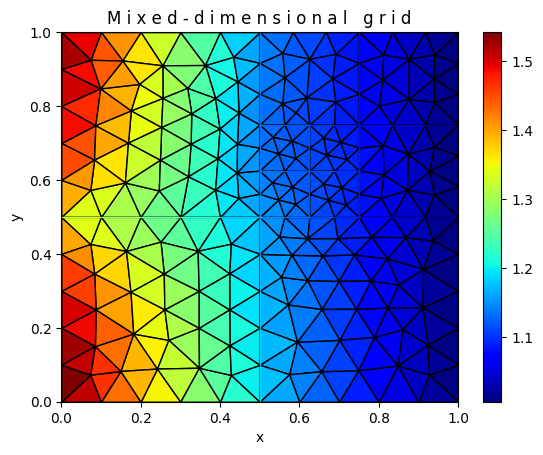

In [2]:
from pp_solvers.solver_mixin import IterativeSolverMixin


class IterativeSolverModel(IterativeSolverMixin, FlowBenchmark2dCase1Model):
    pass


model_params = {
    "material_constants": {"solid": solid_constants_conductive_fractures},
    "grid_type": "simplex",
    "meshing_arguments": {"cell_size": 0.1},
    "linear_solver": {},  # You also need to add this to the model parameters.
}
model = IterativeSolverModel(model_params)
pp.run_time_dependent_model(model)
pp.plot_grid(model.mdg, cell_value='pressure', plot_2d=True)

# Congratulations! Your PorePy model uses the iterative linear solver!

What's next?

You can access the underlying block linear system (matrix and rhs). 

In [3]:
lin_sys = model.bmat
lin_sys

BlockLinearSystem of shape (541, 541) with 5124 elements with 3x3 enabled groups.

It has various visualization tools for debugging and analyzing your problem.

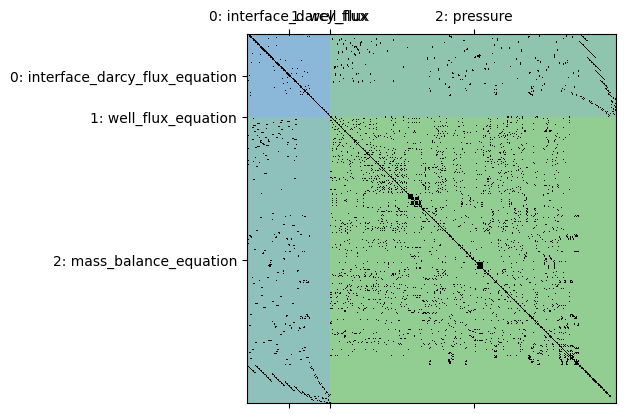

In [4]:
lin_sys.color_spy()

Note that the `well_flux_equation` is formally present, but there are no wells in the model, so it is empty.

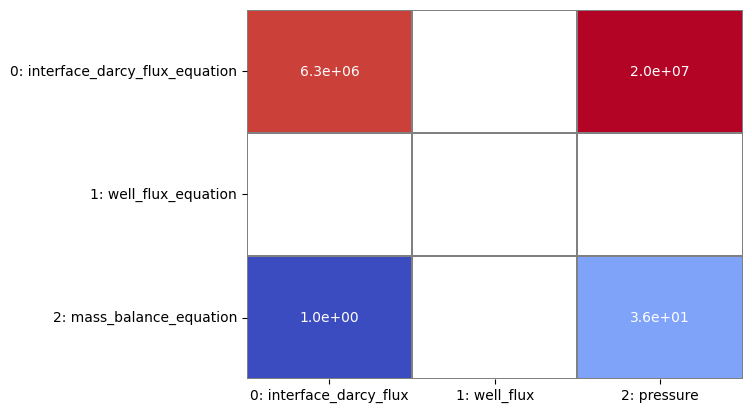

In [5]:
lin_sys.plot_max()

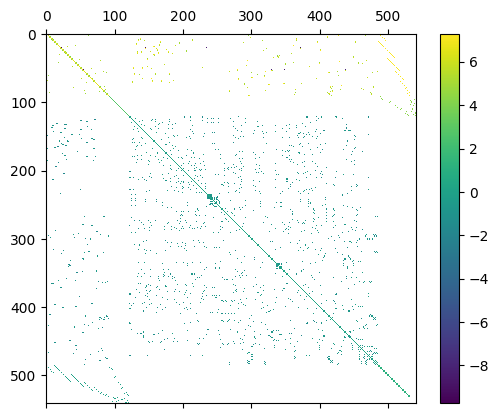

In [6]:
lin_sys.matshow()

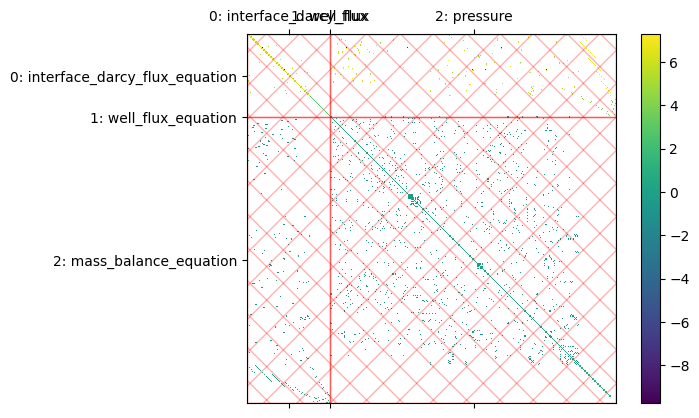

In [7]:
lin_sys.matshow_groups()

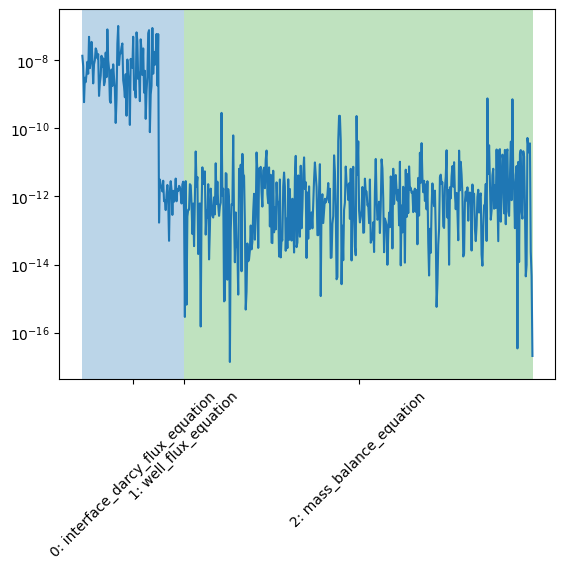

In [8]:
lin_sys.plot_rhs()

You can zoom in to individual submatrices (we refer to them as `groups`). The indices we use to slice submatrices correspond to what `lin_sys.plot_max()` shows above.

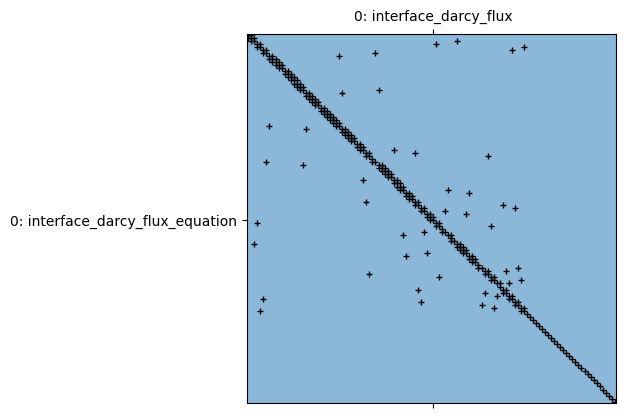

In [9]:
lin_sys_only_interface = lin_sys[0, 0]
lin_sys_only_interface.color_spy()

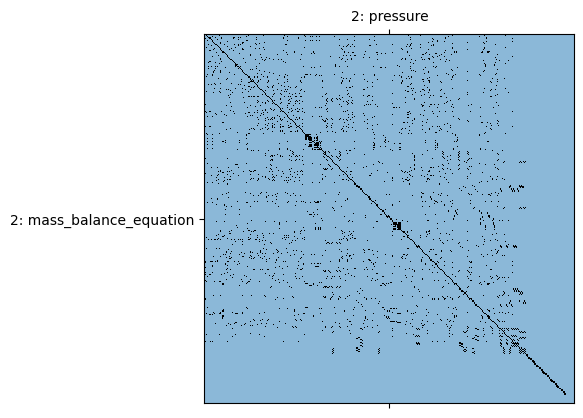

In [10]:
lin_sys_only_pressure = lin_sys[2, 2]
lin_sys_only_pressure.color_spy()